In [1]:
import os
from tqdm.auto import tqdm
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


C:\Users\adrie\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.shape

(110161, 16)

In [3]:
df.columns
df["state"].unique()

<StringArray>
['failed', 'successful']
Length: 2, dtype: str

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Load Embedding Model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# embedding_model = SentenceTransformer(
#     'sentence-transformers/all-mpnet-base-v2',
#     cache_folder='./embedding_models',
#     device=device
# )

embedding_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2',
    device=device
)
# C:\Users\adrie\.cache\huggingface


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2120.07it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Create embeddings (if not yet created)

In [6]:
if not (os.path.exists("../embeddings/train_embeddings.pt") and os.path.exists("../embeddings/test_embeddings.pt")):
    # Drop rows with missing blurbs or labels to avoid errors
    train_df = train_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)
    test_df = test_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)

    print(f"Training samples: {len(train_df)} | Test samples: {len(test_df)}")

    # Compute embeddings for train and test blurbs
    print("Encoding training blurbs...")
    train_embeddings = embedding_model.encode(train_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    print("Encoding test blurbs...")
    test_embeddings = embedding_model.encode(test_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    torch.save(train_embeddings, "embeddings/train_embeddings.pt")
    torch.save(test_embeddings, "embeddings/test_embeddings.pt")

else:
    train_embeddings = torch.load("../embeddings/train_embeddings.pt")
    test_embeddings = torch.load("../embeddings/test_embeddings.pt")


# Creating the Anchors

- Global Anchor: we aggregate all the success embeddings together and all the failed embeddings together and we have to global anchor to compare our embeddings to
- Anchors by category: for each category we create an anchor for the successful and failed blurbs and then we will compare to the anchors of the category for a more precise state prediction

In [7]:
# Ensure train_df is aligned with the saved embeddings (same dropna applied at encoding time)
train_df = train_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)

# 1. Compute Global State Anchors
state_anchors = {}
for state_category in train_df['state'].unique():
    mask = (train_df['state'] == state_category).values
    state_anchors[state_category] = train_embeddings[mask].mean(dim=0)

# 2. Compute State Anchors for each category
category_state_anchors = {}
for parent_category in train_df['category.parent_name'].unique():
    for state_category in train_df['state'].unique():
        mask = (
            (train_df['category.parent_name'] == parent_category) &
            (train_df['state'] == state_category)
        ).values
        if mask.sum() > 0:
            category_state_anchors[(parent_category, state_category)] = train_embeddings[mask].mean(dim=0)

print(f"Created {len(state_anchors)} state anchors and {len(category_state_anchors)} category state anchors.")

C:\Users\adrie\AppData\Local\Temp\ipykernel_25760\3418651737.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  state_anchors[state_category] = train_embeddings[mask].mean(dim=0)


Created 2 state anchors and 30 category state anchors.


## Prediction Global Anchor

In [8]:
# for each test embedding, compute cosine similarity from the global anchor by state and decide which state to predict
test_predictions = []
for test_emb in tqdm(test_embeddings, desc="Predicting states"):
    # Compute cosine similarity to each state anchor
    similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in state_anchors.items()}
    
    # Predict the state with the highest similarity
    predicted_state = max(similarities, key=similarities.get)
    test_predictions.append(predicted_state)

Predicting states: 100%|██████████| 21297/21297 [00:02<00:00, 8621.56it/s] 


Classification Report:
              precision    recall  f1-score   support

      failed       0.58      0.63      0.60      8642
  successful       0.73      0.69      0.71     12655

    accuracy                           0.66     21297
   macro avg       0.66      0.66      0.66     21297
weighted avg       0.67      0.66      0.67     21297

Confusion Matrix:


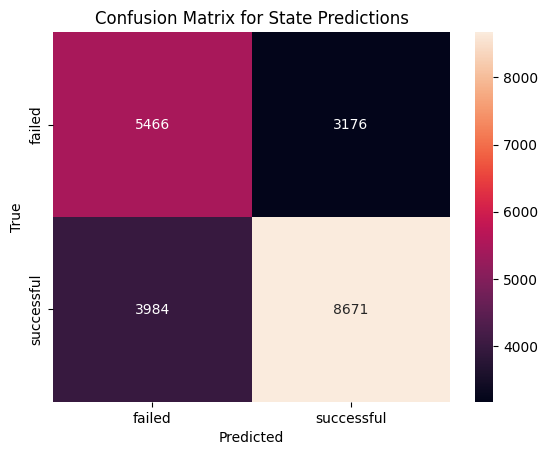

In [9]:
# evaluation, create me a confusion matrix and classification report
true_states = test_df['state'].tolist()
print("Classification Report:")
print(classification_report(true_states, test_predictions))
print("Confusion Matrix:")
cm = confusion_matrix(true_states, test_predictions, labels=list(state_anchors.keys()))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=state_anchors.keys(), yticklabels=state_anchors.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for State Predictions')
plt.show()

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Global Accuracy
accuracy = accuracy_score(true_states, test_predictions)

# 2. Global F1-Score (Macro or Weighted)
# 'weighted' accounts for label imbalance, 'macro' treats all classes equally
f1 = f1_score(true_states, test_predictions, average='weighted')

print(f"Global Accuracy: {accuracy:.4f}")
print(f"Global F1-Score (Weighted): {f1:.4f}")

Global Accuracy: 0.6638
Global F1-Score (Weighted): 0.6658


Computing success similarity: 100%|██████████| 21297/21297 [00:01<00:00, 21175.86it/s]


AUC (success anchor cosine similarity): 0.6091


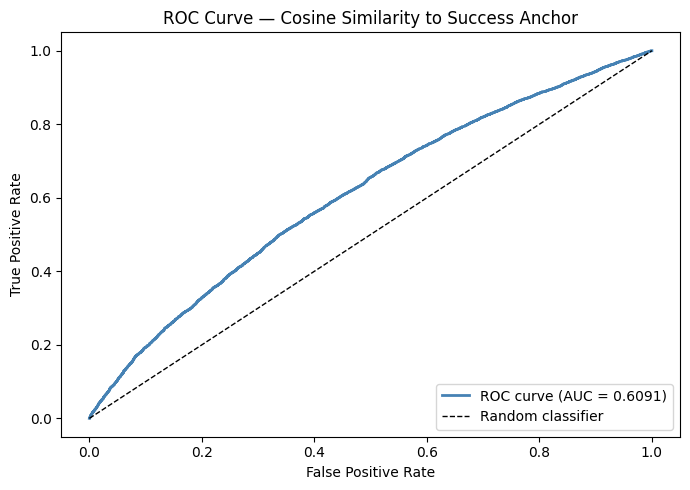

Best threshold (Youden's J): 0.3933  →  TPR=0.4989, FPR=0.3371


In [11]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Compute cosine similarity to the SUCCESS anchor only ---
success_anchor = state_anchors['successful']

# Score = cosine similarity between each test embedding and the success anchor
# Higher score → model is more confident the sample is "successful"
success_scores = [
    util.cos_sim(test_emb, success_anchor).item()
    for test_emb in tqdm(test_embeddings, desc="Computing success similarity")
]

# --- 2. Binarise ground-truth labels (successful=1, failed=0) ---
y_true_binary = [1 if s == 'successful' else 0 for s in true_states]

# --- 3. Compute AUC (no threshold needed – roc_auc_score uses the raw scores) ---
auc = roc_auc_score(y_true_binary, success_scores)
print(f"AUC (success anchor cosine similarity): {auc:.4f}")

# --- 4. Plot ROC curve (sweeps over all thresholds automatically) ---
fpr, tpr, thresholds = roc_curve(y_true_binary, success_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})", color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cosine Similarity to Success Anchor")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- 5. (Optional) Inspect threshold sensitivity ---
# Find the threshold that maximises Youden's J = TPR - FPR
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold (Youden's J): {best_threshold:.4f}  →  TPR={tpr[best_idx]:.4f}, FPR={fpr[best_idx]:.4f}")

## Prediction using Anchor by category

In [12]:
# for each test embedding, compute cosine similarity from the anchors by state of its category and decide which state to predict
test_predictions_category = []
for idx, test_emb in tqdm(enumerate(test_embeddings), desc="Predicting states by category", total=len(test_embeddings)):
    parent_category = test_df.iloc[idx]['category.parent_name']

    # Get all state anchors available for this parent category
    category_anchors = {
        state: anchor
        for (cat, state), anchor in category_state_anchors.items()
        if cat == parent_category
    }

    if category_anchors:
        # Compute cosine similarity to each state anchor and pick the best one
        similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in category_anchors.items()}
        predicted_state = max(similarities, key=similarities.get)
    else:
        # Fall back to global anchors when no category-specific anchors are available
        similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in state_anchors.items()}
        predicted_state = max(similarities, key=similarities.get)

    test_predictions_category.append(predicted_state)


Predicting states by category:   0%|          | 0/21297 [00:00<?, ?it/s]

Predicting states by category: 100%|██████████| 21297/21297 [00:04<00:00, 5030.73it/s]


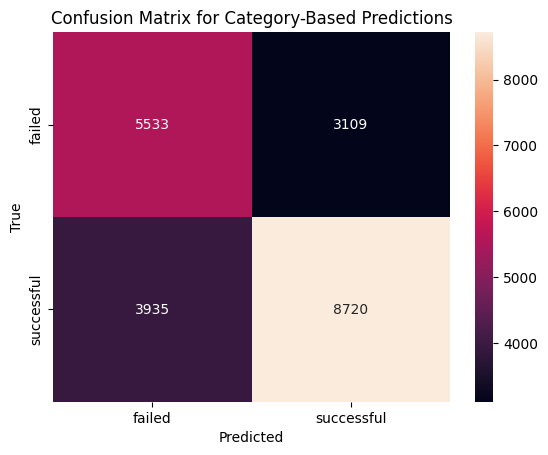

In [13]:
# plot one confusion matrix for the each category
cm_category = confusion_matrix(true_states, test_predictions_category, labels=list(state_anchors.keys()))
sns.heatmap(cm_category, annot=True, fmt='d', xticklabels=state_anchors.keys(), yticklabels=state_anchors.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Category-Based Predictions')
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_fscore_support
import pandas as pd
import numpy as np

# 1. Add predictions to your dataframe for easy grouping
test_df['predicted_state'] = test_predictions_category
test_df['true_state'] = true_states

categories = test_df['category.parent_name'].unique()
category_metrics = []

for cat in categories:
    cat_df = test_df[test_df['category.parent_name'] == cat]
    
    if len(cat_df) == 0:
        continue
        
    y_true = cat_df['true_state']
    y_pred = cat_df['predicted_state']
    
    # Calculate metrics for this specific category
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # Weight is usually based on the number of samples in the category
    weight = len(cat_df)
    
    category_metrics.append({
        'category': cat,
        'accuracy': acc,
        'f1': f1,
        'weight': weight
    })

# 2. Convert to DataFrame to calculate weighted averages
metrics_df = pd.DataFrame(category_metrics)
total_samples = metrics_df['weight'].sum()

global_weighted_acc = (metrics_df['accuracy'] * metrics_df['weight']).sum() / total_samples
global_weighted_f1 = (metrics_df['f1'] * metrics_df['weight']).sum() / total_samples

print(f"Global Weighted Accuracy: {global_weighted_acc:.4f}")
print(f"Global Weighted F1 Score: {global_weighted_f1:.4f}")

Global Weighted Accuracy: 0.6692
Global Weighted F1 Score: 0.6806


Computing category success similarity: 100%|██████████| 21297/21297 [00:01<00:00, 12150.78it/s]


Global AUC (category anchors): 0.5989
Weighted AUC across categories: 0.5902
    category      auc  weight
       Games 0.652807    1611
 Photography 0.645001     579
      Design 0.624452     832
       Music 0.622399    3039
     Theater 0.618303     538
  Technology 0.617883    1812
  Publishing 0.601965    2558
     Fashion 0.592332     837
Film & Video 0.582597    3389
       Dance 0.581232     173
         Art 0.554532    2047
  Journalism 0.544554     352
      Comics 0.538540    1411
      Crafts 0.524089     480
        Food 0.507608    1639


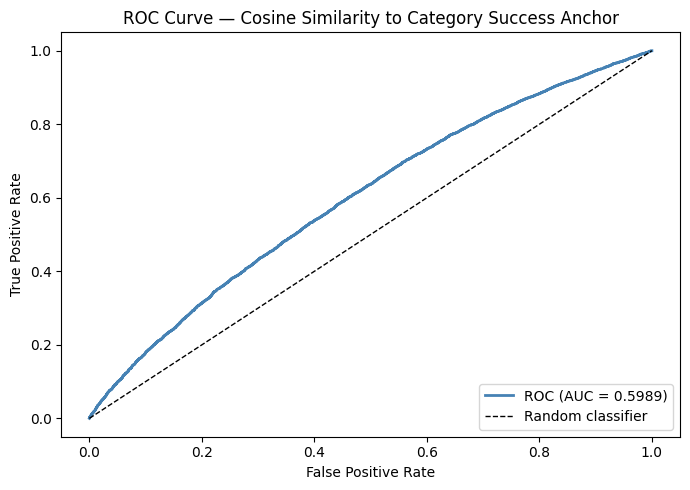

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# --- 1. For each test sample, score = cos_sim to its OWN category's success anchor ---
success_scores_cat = []
for idx, test_emb in tqdm(enumerate(test_embeddings), desc="Computing category success similarity", total=len(test_embeddings)):
    parent_category = test_df.iloc[idx]['category.parent_name']
    
    # Use category-specific success anchor, fall back to global if missing
    if (parent_category, 'successful') in category_state_anchors:
        anchor = category_state_anchors[(parent_category, 'successful')]
    else:
        anchor = state_anchors['successful']
    
    score = util.cos_sim(test_emb, anchor).item()
    success_scores_cat.append(score)

# --- 2. Binarise labels ---
y_true_binary = [1 if s == 'successful' else 0 for s in true_states]

# --- 3. Global AUC using category-specific scores ---
auc_global = roc_auc_score(y_true_binary, success_scores_cat)
print(f"Global AUC (category anchors): {auc_global:.4f}")

# --- 4. Weighted AUC across categories ---
test_df['success_score'] = success_scores_cat
test_df['true_binary'] = y_true_binary

category_aucs = []
for cat, cat_df in test_df.groupby('category.parent_name'):
    # AUC requires both classes to be present
    if cat_df['true_binary'].nunique() < 2:
        continue
    cat_auc = roc_auc_score(cat_df['true_binary'], cat_df['success_score'])
    category_aucs.append({'category': cat, 'auc': cat_auc, 'weight': len(cat_df)})

aucs_df = pd.DataFrame(category_aucs)
weighted_auc = (aucs_df['auc'] * aucs_df['weight']).sum() / aucs_df['weight'].sum()
print(f"Weighted AUC across categories: {weighted_auc:.4f}")
print(aucs_df.sort_values('auc', ascending=False).to_string(index=False))

# --- 5. ROC curve (global, using category-specific scores) ---
fpr, tpr, thresholds = roc_curve(y_true_binary, success_scores_cat)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_global:.4f})", color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cosine Similarity to Category Success Anchor")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()